# Neutral-atom quantum computing for multi-hypothesis tracking

Run every cell top to bottom. The notebook detects cells in one image,
associates them with tracks, and plots the result.

- If the real `data/PhC-C2DL-PSC` sequence is present it is used;
  otherwise a synthetic sequence is generated locally so **Run All always works**.
- Switch to the quantum solver in the configuration cell
  (requires `python -m pip install -e ".[quantum]"`).
- Set `RUN_MANY_FRAMES = True` in the last cell to track over a sequence.

In [1]:
# Imports: make the local src-layout package available before importing it.
from pathlib import Path
import sys

import matplotlib.pyplot as plt

project_root = Path.cwd().resolve()
source_root = project_root / "src"
if not (project_root / "pyproject.toml").is_file() or not source_root.is_dir():
    raise RuntimeError("Open user_notebook.ipynb from the repository root.")
if str(source_root) not in sys.path:
    sys.path.insert(0, str(source_root))

from neutral_atom_mht import (
    ClassicalSolver,
    DEFAULT_SYNTHETIC_DATA_ROOT,
    HPC,
    HPCConfig,
    QuantumSolver,
    SyntheticDataConfig,
    SyntheticDataGenerator,
    SyntheticDataset,
)
from cell_data import DATASET_NAME, FRAME_COUNT, load_tiff, raw_frame_path

In [2]:
# Data: use the real sequence when present, otherwise generate or reuse a
# local synthetic sequence so the notebook always runs out of the box.
frame = 0
real_dataset_root = project_root / "data" / DATASET_NAME
USE_SYNTHETIC_DATA = not raw_frame_path(real_dataset_root, frame).is_file()

synthetic_data_config = SyntheticDataConfig(
    noise=0.6,
    frame_count=40,
    object_count=55,
    seed=0,
)
synthetic_output_root = project_root / DEFAULT_SYNTHETIC_DATA_ROOT
synthetic_dataset = SyntheticDataset(
    root=synthetic_output_root / synthetic_data_config.dataset_name,
    config=synthetic_data_config,
)
if USE_SYNTHETIC_DATA and not synthetic_dataset.raw_frame_path(0).is_file():
    print(f"Real data not found; generating {synthetic_dataset.root} ...")
    synthetic_dataset = SyntheticDataGenerator(synthetic_data_config).generate(
        synthetic_output_root
    )
    print("Synthetic sequence generated.")

In [3]:
# Configuration: resolve the selected data source and choose a solver.
if USE_SYNTHETIC_DATA:
    dataset_root = synthetic_dataset.root
    frame_path = synthetic_dataset.raw_frame_path(frame)
    sequence = synthetic_dataset.config.sequence
    dataset_label = synthetic_data_config.dataset_name
    available_frames = synthetic_data_config.frame_count
else:
    dataset_root = real_dataset_root
    frame_path = raw_frame_path(dataset_root, frame)
    sequence = "01"
    dataset_label = DATASET_NAME
    available_frames = FRAME_COUNT
print(f"Using {dataset_label} sequence {sequence}: {frame_path}")

config = HPCConfig()
controller = HPC(config, sequence=sequence)
# The default synthetic sequence reaches 40-node graph components.
solver = ClassicalSolver(maximum_component_nodes=60)
# Optional quantum simulation (requires `python -m pip install -e ".[quantum]"`).
# Start with one frame: each non-clique component is simulated separately.
# solver = QuantumSolver()

Using SYN-MHT sequence 01: C:\Projects\Summer School Challenge\Neutral-Atom-QC-for-MHT\data\synthetic\SYN-MHT\01\t000.tif


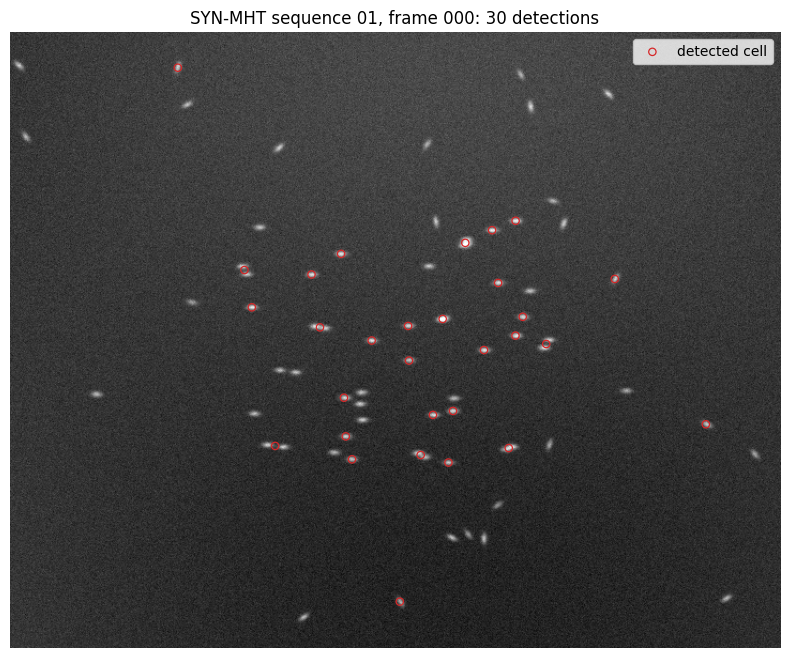

{'dataset': 'SYN-MHT',
 'frame_path': 'C:\\Projects\\Summer School Challenge\\Neutral-Atom-QC-for-MHT\\data\\synthetic\\SYN-MHT\\01\\t000.tif',
 'detections': 30,
 'initialized_tracks': 30,
 'solver': 'classical_exact'}

In [4]:
# Run: detect the cells, create tracks, and show the detections on the source frame.
image = load_tiff(frame_path)
prepared = controller.prepare_frame(image, frame=frame)
solver_result = controller.solve(prepared, solver)
result = controller.advance(prepared, solver_result)
detections = prepared.observed_frame.detection.detections

figure, axis = plt.subplots(figsize=(10, 8))
axis.imshow(image, cmap="gray")
axis.scatter(
    [detection.x_px for detection in detections],
    [detection.y_px for detection in detections],
    s=28,
    facecolors="none",
    edgecolors="tab:red",
    linewidths=0.9,
    label="detected cell",
)
axis.set_title(
    f"{dataset_label} sequence {sequence}, frame {frame:03d}: "
    f"{len(detections)} detections"
)
axis.set_axis_off()
axis.legend(loc="upper right")
plt.show()

{
    "dataset": dataset_label,
    "frame_path": str(frame_path),
    "detections": len(detections),
    "initialized_tracks": len(result.tracks),
    "solver": solver.solver_name,
}

In [5]:
# Optional multi-frame run: enable explicitly, especially before using QuantumSolver.
RUN_MANY_FRAMES = False
MANY_FRAME_COUNT = 40
sequence_summary = None
if RUN_MANY_FRAMES:
    frames_to_run = min(MANY_FRAME_COUNT, available_frames)
    if frames_to_run < 1:
        raise ValueError("MANY_FRAME_COUNT must be positive")

    if USE_SYNTHETIC_DATA:
        frame_paths = [
            synthetic_dataset.raw_frame_path(frame_index)
            for frame_index in range(frames_to_run)
        ]
    else:
        frame_paths = [
            raw_frame_path(dataset_root, frame_index)
            for frame_index in range(frames_to_run)
        ]
    images = (load_tiff(path) for path in frame_paths)

    sequence_controller = HPC(config, sequence=sequence)
    sequence_result = sequence_controller.run_sequence(
        images, solver, start_frame=0
    )
    processed_frames = [step.frame for step in sequence_result.steps]
    active_tracks = [len(step.tracks) for step in sequence_result.steps]
    assigned_observations = [
        len(step.assigned_observation_ids) for step in sequence_result.steps
    ]

    figure, axis = plt.subplots(figsize=(10, 4))
    axis.plot(processed_frames, active_tracks, label="active tracks")
    axis.plot(
        processed_frames,
        assigned_observations,
        label="assigned observations",
    )
    axis.set(
        xlabel="frame",
        ylabel="count",
        title=(
            f"{dataset_label}: {frames_to_run} frames with "
            f"{sequence_result.solver_name}"
        ),
    )
    axis.grid(alpha=0.25)
    axis.legend()
    plt.show()

    sequence_summary = {
        "frames_processed": len(sequence_result.steps),
        "final_tracks": len(sequence_result.final_tracks),
        "solver": sequence_result.solver_name,
        "solver_runtime_seconds": sum(
            step.solver_result.runtime_seconds for step in sequence_result.steps
        ),
    }
sequence_summary